In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
from sklearn.metrics import r2_score
from tqdm import tqdm

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src')))
from dataloadermaker import DataLoaderMaker
import vis_utils as vu
import probabilistic_utils as pu

USE_MACOS = True 
if USE_MACOS:
    pytensor.config.cxx = ""

In [5]:
fp_folder = '/Users/tplas/data/2025-06-16 moth data Natalie'
contents = [x for x in os.listdir(fp_folder) if x[0] not in ['.', '~']]
contents

['1994-2019_field-d50.csv',
 '1994-2019_field-d50.xlsx',
 '1994-2019_KNMI_DeBilt_hourly.txt']

In [57]:
def load_and_prep_moth_data(fp_path, hv_only=True):
    df_moth = pd.read_csv(fp_path, header=0, sep=';')
    assert len(df_moth) == 5792, "Expected 5792 rows in the moth data from excel file, but found a different number."
    if hv_only:
        df_moth = df_moth[df_moth['AreaShortName'] == 'HV']
    # Calculate DOY_hatch as the day of year for April in YearHatch
    df_moth['D50Calc'] = df_moth['D50Calc'].apply(lambda x: float(str(x).replace(',', '.')))
    df_moth['D50Calc'] = df_moth['D50Calc'].round(0).astype(int)
    df_moth['MonthHatch'] = -1 
    df_moth['DayHatch'] = -1
    for id, row in df_moth.iterrows():
        if row['D50Calc'] < 61 and row['D50Calc'] > 30:
            df_moth.loc[id, 'MonthHatch'] = 5
            df_moth.loc[id, 'DayHatch'] = row['D50Calc'] - 30
        elif row['D50Calc'] < 1 and row['D50Calc'] > -30:
            df_moth.loc[id, 'MonthHatch'] = 3
            df_moth.loc[id, 'DayHatch'] = 31 + row['D50Calc']
        elif row['D50Calc'] < 31 and row['D50Calc'] > 0:
            df_moth.loc[id, 'MonthHatch'] = 4
            df_moth.loc[id, 'DayHatch'] = row['D50Calc']
        else:
            assert False, f"Unexpected D50Calc value {row['D50Calc']} for row {id}: {row}"
    df_moth['DOY_hatch'] = pd.to_datetime(dict(year=df_moth['YearHatch'], month=df_moth['MonthHatch'], day=df_moth['DayHatch'])).dt.dayofyear
    
    df_moth = df_moth[['YearHatch', 'DOY_hatch', 'AreaShortName', 'Site', 'Tree']]
    return df_moth

df_moth = load_and_prep_moth_data(os.path.join(fp_folder, contents[0]))
df_moth

,YearHatch,DOY_hatch,AreaShortName,Site,Tree
0,1995,105,HV,98,4
1,1995,98,HV,98,44
2,1995,91,HV,98,11
3,1995,98,HV,98,41
4,1995,98,HV,98,41
...,...,...,...,...,...
5622,2019,91,HV,4,8
5623,2019,96,HV,7,8
5694,2019,98,HV,1,4
5695,2019,98,HV,1,6


Text(0, 0.5, 'Number of observations')

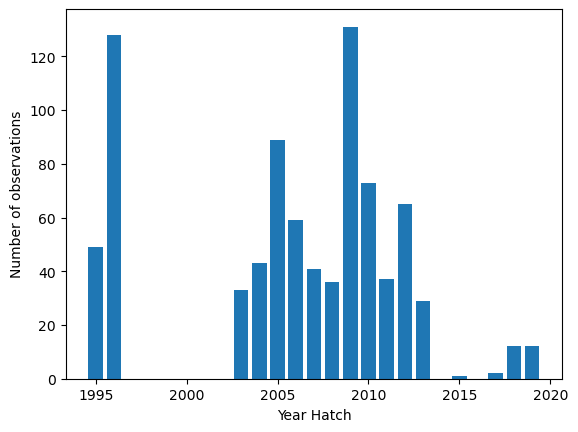

In [59]:
from collections import Counter
tmp = Counter(df_moth['YearHatch'])
plt.bar(height=tmp.values(), x=tmp.keys())
plt.xlabel('Year Hatch')
plt.ylabel('Number of observations')

In [63]:
VeluweTreeData = DataLoaderMaker()
VeluweTreeData.load()
temp_df = VeluweTreeData.get("temp_climwin_input")


In [64]:
pu.prep_budburst_data_for_regression()

No data provided -- using default data
No location list provided, using all locations


,bb_cdf,date,temperature,season
0,0.0,1987-12-01 00:00:00+00:00,2.036997,1987-1988
1,0.0,1987-12-02 00:00:00+00:00,1.764124,1987-1988
2,0.0,1987-12-03 00:00:00+00:00,1.126213,1987-1988
3,0.0,1987-12-04 00:00:00+00:00,-0.597208,1987-1988
4,0.0,1987-12-05 00:00:00+00:00,-0.668622,1987-1988
...,...,...,...,...
6556,1.0,2023-05-27 00:00:00+00:00,14.216854,2022-2023
6557,1.0,2023-05-28 00:00:00+00:00,16.112461,2022-2023
6558,1.0,2023-05-29 00:00:00+00:00,12.913763,2022-2023
6559,1.0,2023-05-30 00:00:00+00:00,12.912954,2022-2023


In [65]:
pu.prep_moth_data_for_regression(moth_df=df_moth, temp_df=temp_df)

<string>:16: RuntimeWarning: invalid value encountered in floor_divide


,moth_cdf,date,temperature,season
0,0.0,1994-12-01 00:00:00+00:00,3.358087,1994-1995
1,0.0,1994-12-02 00:00:00+00:00,1.960794,1994-1995
2,0.0,1994-12-03 00:00:00+00:00,7.626090,1994-1995
3,0.0,1994-12-04 00:00:00+00:00,9.356979,1994-1995
4,0.0,1994-12-05 00:00:00+00:00,9.008084,1994-1995
...,...,...,...,...
3093,1.0,2019-05-27 00:00:00+00:00,14.090170,2018-2019
3094,1.0,2019-05-28 00:00:00+00:00,10.768054,2018-2019
3095,1.0,2019-05-29 00:00:00+00:00,12.626536,2018-2019
3096,1.0,2019-05-30 00:00:00+00:00,16.648355,2018-2019
